# Modelos de Potencial Intermolecular para el Deuterio (D₂)
---

### Table of Contents

1. [Introduction & Physical Background](#1-introduction)
2. [Imports & Physical Constants](#2-imports)
3. [Experimental Data](#3-data)
4. [Model 1 — Square-Well Potential](#4-model1)
5. [Model 2 — General (Mie) Potential](#5-model2)
6. [Model Comparison & Error Analysis](#6-comparison)
7. [Conclusions](#7-conclusions)

<a id="1-introduction"></a>
## 1. Introduction & Physical Background

The **second virial coefficient** $B(T)$ captures pair-wise molecular interactions and is computed from an intermolecular potential $u(r)$ via the **Mayer integral**:

$$B(T) = -2\pi N_A \int_0^\infty \left[\exp\!\left(-\frac{u(r)}{k_B T}\right) - 1\right] r^2 \, dr$$

where $N_A$ is Avogadro's number, $k_B$ is Boltzmann's constant, and $r$ is the intermolecular distance.

**Goal**: Fit two different potential models to experimental $B(T)$ data for deuterium and **minimize the model error** to find the best-fit parameters.

### The two models:

| Model | Potential $u(r)$ | Parameters to fit |
|---|---|---|
| **Square-Well** | $u = \infty$ for $r < \sigma$; $u = -\varepsilon$ for $\sigma < r < a$; $u = 0$ for $r > a$ | $\varepsilon$ (well depth), $a$ (well width) |
| **Mie (General)** | $u(r) = \varepsilon\dfrac{m}{m-6}\left(\dfrac{m}{6}\right)^{6/(m-6)}\left[\left(\dfrac{\sigma}{r}\right)^m - \left(\dfrac{\sigma}{r}\right)^6\right]$ | $\varepsilon$ (well depth), $m$ (repulsive exponent) |

The molecular collision diameter of deuterium is: $\sigma = 2.928\;\text{Å} = 2.928 \times 10^{-10}\;\text{m}$ (standard Lennard-Jones parameter from literature).

<a id="2-imports"></a>
## 2. Imports & Physical Constants

In [ ]:
# ── Imports ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.integrate import quad
from sklearn.metrics import r2_score, mean_squared_error

# ── Physical constants ─────────────────────────────────────────────────────
# effective collision diameter. Literature value for D₂: σ ≈ 2.928 Å.
sigma = 2.928e-10        # Molecular diameter of D₂ [m] (literature LJ value)
Na    = 6.022e23         # Avogadro's number [molecules/mol]
kB    = 1.380649e-23     # Boltzmann constant [J/K]

# Hard-sphere limit: b₀ = (2/3)πNaσ³  (B → b₀ as T → ∞)
b0 = (2/3) * np.pi * Na * sigma**3 #Revisar
print(f"σ   = {sigma:.4e} m  ({sigma*1e10:.3f} Å)")
print(f"Nₐ  = {Na:.4e} mol⁻¹")
print(f"kB  = {kB:.6e} J/K")
print(f"b₀  = {b0:.4e} m³/mol  = {b0*1e6:.2f} cm³/mol  (hard-sphere asymptote)")

σ   = 2.9280e-10 m  (2.928 Å)
Nₐ  = 6.0220e+23 mol⁻¹
kB  = 1.380649e-23 J/K
b₀  = 3.1660e-05 m³/mol  = 31.66 cm³/mol  (hard-sphere asymptote)


<a id="3-data"></a>
## 3. Experimental Data

We load the experimental second virial coefficient $B(T)$ data for deuterium from an Excel file. Visualizing the data first helps us understand the trend and set reasonable initial guesses for the optimization.

Number of data points: 29
Temperature range: 84.0 – 420.0 K
B(T) range: -10.40 – 15.50 cm³/mol

Data preview:
     T     B
 84.00 -10.4
 88.00  -8.7
 92.00  -7.0
 96.00  -5.0
100.00  -4.2
110.00  -1.3
115.00   0.0
120.00   1.0
130.00   3.0
140.00   4.6
150.00   6.0
160.00   7.1
170.00   8.1
180.00   8.9
190.00   9.5
200.00  10.2
220.00  11.3
240.00  12.2
260.00  12.8
273.15  13.1
280.00  13.2
300.00  13.5
320.00  14.0
340.00  14.4
360.00  14.7
373.15  14.9
380.00  15.0
400.00  15.2
420.00  15.5


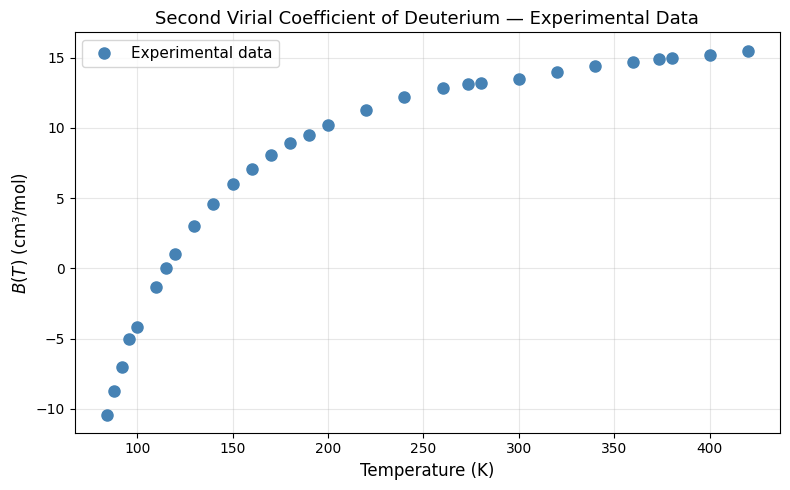

In [10]:
# ── Load experimental data ──────────────────────────────────────────────────
df = pd.read_csv('Datos Deuterio.csv')
T_data = df['T'].to_numpy()   # Temperature [K]
B_data = df['B'].to_numpy()   # Second virial coefficient [cm³/mol]

print(f"Number of data points: {len(T_data)}")
print(f"Temperature range: {T_data.min():.1f} – {T_data.max():.1f} K")
print(f"B(T) range: {B_data.min():.2f} – {B_data.max():.2f} cm³/mol")
print(f"\nData preview:")
print(df.to_string(index=False))

# ── Visualize the raw data ─────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(T_data, B_data, 'o', color='steelblue', markersize=8, label='Experimental data')
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel('$B(T)$ (cm³/mol)', fontsize=12)
plt.title('Second Virial Coefficient of Deuterium — Experimental Data', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id="4-model1"></a>
## 4. Model 1 — Square-Well Potential

The **square-well potential** is the simplest attractive model:

$$u(r) = \begin{cases} \infty & r < \sigma \\ -\varepsilon & \sigma \le r < a \\ 0 & r \ge a \end{cases}$$

where $\varepsilon > 0$ is the well depth and $a > \sigma$ is the outer radius of the square well.

Substituting into the **Mayer integral** $B = -2\pi N_A \int_0^\infty [e^{-u/k_BT} - 1]\,r^2\,dr$, the closed-form result is:

$$\boxed{B(T) = \frac{2\pi N_A}{3} \left[\sigma^3 - \left(a^3 - \sigma^3\right)\left(\exp\!\left(\frac{\varepsilon}{k_B T}\right) - 1\right)\right]}$$

> **Key physics**: At high $T$, $\exp(\varepsilon/k_BT) \to 1$, so $B \to \frac{2\pi N_A}{3}\sigma^3 = b_0 > 0$ (hard-sphere repulsion).  
> At low $T$, the exponential diverges, so $B \to -\infty$ (attraction dominates).

We minimize the **sum of squared errors (SSE)** to find the optimal $\varepsilon$ and $a$:

$$\text{SSE} = \frac{1}{2}\sum_{i=1}^{n}\left(B_i^{\text{exp}} - B_i^{\text{model}}\right)^2$$

Initial guesses:  ε₀/kB = 35.0 K,  a₀/σ = 1.60
                  ε₀ = 4.8323e-22 J,  a₀ = 4.6848e-10 m
Optimization terminated successfully.
         Current function value: 234.665189
         Iterations: 4979
         Function evaluations: 9171

  Square-Well Fitted Parameters
  ε (well depth)  = 1.402245e-27 J  (ε/kB = 0.00 K)
  a (well radius) = 3.112167e-08 m  (a/σ = 106.2898)
  Final SSE       = 2.346652e+02

  R² = 0.744737
  RMSE = 4.0229 cm³/mol


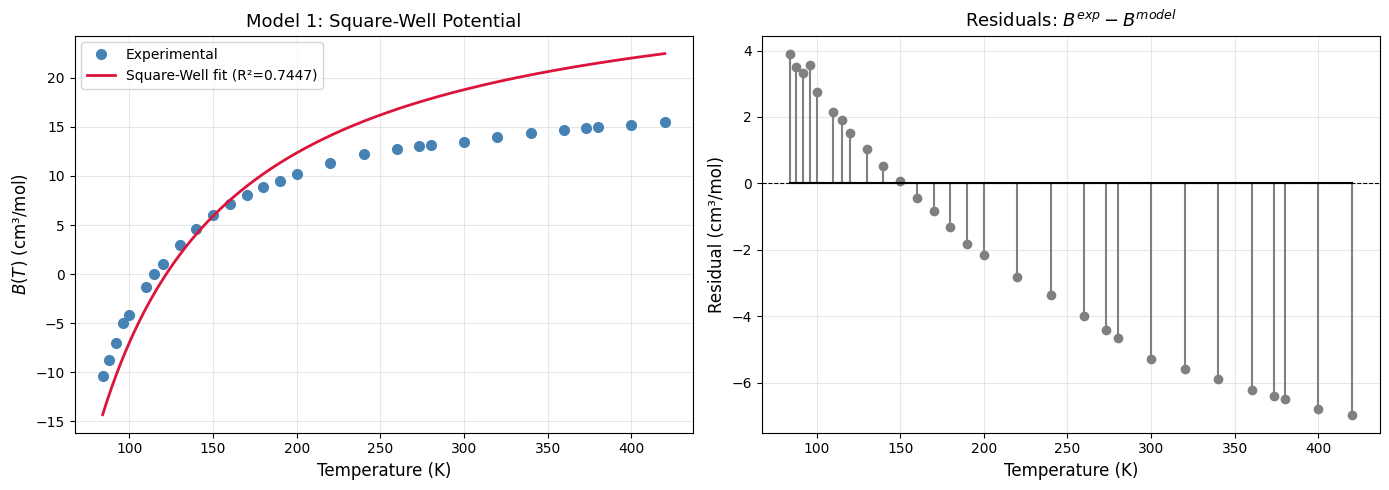

In [11]:
# ── Model 1: Square-Well B(T) ───────────────────────────────────────────────
def B_square_well(params, T):
    """Second virial coefficient for the square-well potential.
    
    B(T) = (2πNa/3)[σ³ - (a³ - σ³)(exp(ε/(kBT)) - 1)]
    Returns B in cm³/mol.
    """
    epsilon, a = params
    B_m3 = (2 * np.pi * Na / 3) * (
        sigma**3 - (a**3 - sigma**3) * (np.exp(epsilon / (kB * T)) - 1)
    )
    return B_m3 * 1e6   # m³/mol → cm³/mol

def calc_SSE(params, T, B_exp):
    """Sum of squared errors (SSE) between model and experiment."""
    residuals = B_exp - B_square_well(params, T)
    return 0.5 * np.dot(residuals, residuals)

# ── Initial guesses ────────────────────────────────────────────────────────
# ε/kB ~ 35 K (typical for D₂);  a/σ ~ 1.6 (well extends 60% beyond hard core)
epsilon_0 = 35.0 * kB        # [J]  →  ε/kB ≈ 35 K
a_0       = 1.6 * sigma      # [m]  →  λ = a/σ ≈ 1.6
params_0  = [epsilon_0, a_0]
print(f"Initial guesses:  ε₀/kB = {epsilon_0/kB:.1f} K,  a₀/σ = {a_0/sigma:.2f}")
print(f"                  ε₀ = {epsilon_0:.4e} J,  a₀ = {a_0:.4e} m")

# ── Optimization using Nelder-Mead (derivative-free) ──────────────────────
result_SW = minimize(calc_SSE, params_0, args=(T_data, B_data),
                     method='Nelder-Mead',
                     options={'disp': True, 'maxiter': 50000,
                              'xatol': 1e-15, 'fatol': 1e-12})

eps_fit, a_fit = result_SW.x
print(f"\n{'='*55}")
print(f"  Square-Well Fitted Parameters")
print(f"{'='*55}")
print(f"  ε (well depth)  = {eps_fit:.6e} J  (ε/kB = {eps_fit/kB:.2f} K)")
print(f"  a (well radius) = {a_fit:.6e} m  (a/σ = {a_fit/sigma:.4f})")
print(f"  Final SSE       = {result_SW.fun:.6e}")
print(f"{'='*55}")

# ── Evaluate model and compute error metrics ──────────────────────────────
B_pred_SW = B_square_well([eps_fit, a_fit], T_data)
R2_SW     = r2_score(B_data, B_pred_SW)
RMSE_SW   = np.sqrt(mean_squared_error(B_data, B_pred_SW))
print(f"\n  R² = {R2_SW:.6f}")
print(f"  RMSE = {RMSE_SW:.4f} cm³/mol")

# ── Plot fitted model vs. data ────────────────────────────────────────────
T_smooth   = np.linspace(T_data.min(), T_data.max(), 500)
B_model_SW = B_square_well([eps_fit, a_fit], T_smooth)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Fit
axes[0].plot(T_data, B_data, 'o', color='steelblue', ms=7, label='Experimental')
axes[0].plot(T_smooth, B_model_SW, '-', color='crimson', lw=2,
             label=f'Square-Well fit (R²={R2_SW:.4f})')
axes[0].set_xlabel('Temperature (K)', fontsize=12)
axes[0].set_ylabel('$B(T)$ (cm³/mol)', fontsize=12)
axes[0].set_title('Model 1: Square-Well Potential', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: Residuals
residuals_SW = B_data - B_pred_SW
axes[1].stem(T_data, residuals_SW, linefmt='grey', markerfmt='o', basefmt='k-')
axes[1].axhline(y=0, color='black', ls='--', lw=0.8)
axes[1].set_xlabel('Temperature (K)', fontsize=12)
axes[1].set_ylabel('Residual (cm³/mol)', fontsize=12)
axes[1].set_title('Residuals: $B^{exp} - B^{model}$', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a id="5-model2"></a>
## 5. Model 2 — General (Mie) Potential

The **Mie potential** generalizes the Lennard-Jones form by allowing a variable repulsive exponent $m$:

$$u(r) = \varepsilon \cdot \frac{m}{m-6}\left(\frac{m}{6}\right)^{6/(m-6)} \left[\left(\frac{\sigma}{r}\right)^m - \left(\frac{\sigma}{r}\right)^6\right]$$

For $m = 12$ this reduces to the classic **Lennard-Jones (12-6)** potential.

Since no closed-form $B(T)$ exists for the Mie potential, we compute the Mayer integral **numerically** using `scipy.integrate.quad`:

$$B(T) = -2\pi N_A \int_0^\infty \left[\exp\!\left(-\frac{u(r)}{k_B T}\right) - 1\right] r^2 \, dr$$

The integral is split at $r = \sigma$ for numerical stability:
- For $r < \sigma$: the potential is strongly repulsive, so $e^{-u/k_BT} \approx 0$ and the integrand $\approx -r^2$ (hard-core contribution)
- For $r > \sigma$: the full integrand is evaluated numerically

In [12]:
# ── Model 2: Mie potential B(T) via numerical integration ──────────────────
def mie_potential(r, epsilon, m):
    """Mie (generalized Lennard-Jones) potential."""
    C = epsilon * (m / (m - 6)) * (m / 6) ** (6 / (m - 6))
    return C * ((sigma / r) ** m - (sigma / r) ** 6)

def B_mie(params, T_arr):
    """Second virial coefficient for the Mie potential.
    
    B(T) = -2πNa ∫₀^∞ [exp(-u(r)/(kBT)) - 1] r² dr
    
    Split at r = σ for numerical stability:
      - r < σ:  hard-core region, integrand ≈ -r²  (analytical: -σ³/3)
      - r ≥ σ:  numerically integrated with scipy.integrate.quad
    
    Returns B in cm³/mol.
    """
    epsilon, m = params
    results = []
    
    for T in np.atleast_1d(T_arr):
        # Hard-core contribution: ∫₀^σ (-1)r² dr = -σ³/3
        hard_core = -sigma**3 / 3.0
        
        # Soft (attractive + repulsive) region: numerical integration
        def integrand(r):
            u = mie_potential(r, epsilon, m)
            return (np.exp(-u / (kB * T)) - 1.0) * r**2
        
        soft_part, _ = quad(integrand, sigma, 50 * sigma, limit=500)
        
        B_val = -2 * np.pi * Na * (hard_core + soft_part)  # [m³/mol]
        results.append(B_val * 1e6)  # → cm³/mol
    
    return np.array(results)

# Quick test: evaluate B at one temperature
B_test = B_mie([40 * kB, 12.0], np.array([300.0]))
print(f"Test: B(300 K) with ε/kB=40 K, m=12 → {B_test[0]:.2f} cm³/mol")
print("Numerical integration setup complete.")

Test: B(300 K) with ε/kB=40 K, m=12 → 20.10 cm³/mol
Numerical integration setup complete.


Initial guesses:  ε₀/kB = 40.0 K,  m₀ = 12.0

Optimizing... (this may take a minute due to numerical integration)
Optimization terminated successfully.
         Current function value: 290.176220
         Iterations: 158
         Function evaluations: 332

  Mie Potential Fitted Parameters
  ε (well depth)       = 5.663697e-22 J  (ε/kB = 41.02 K)
  m (repulsive exp.)   = 11.6346
  Final SSE            = 2.901762e+02

  R² = 0.684353
  RMSE = 4.4735 cm³/mol


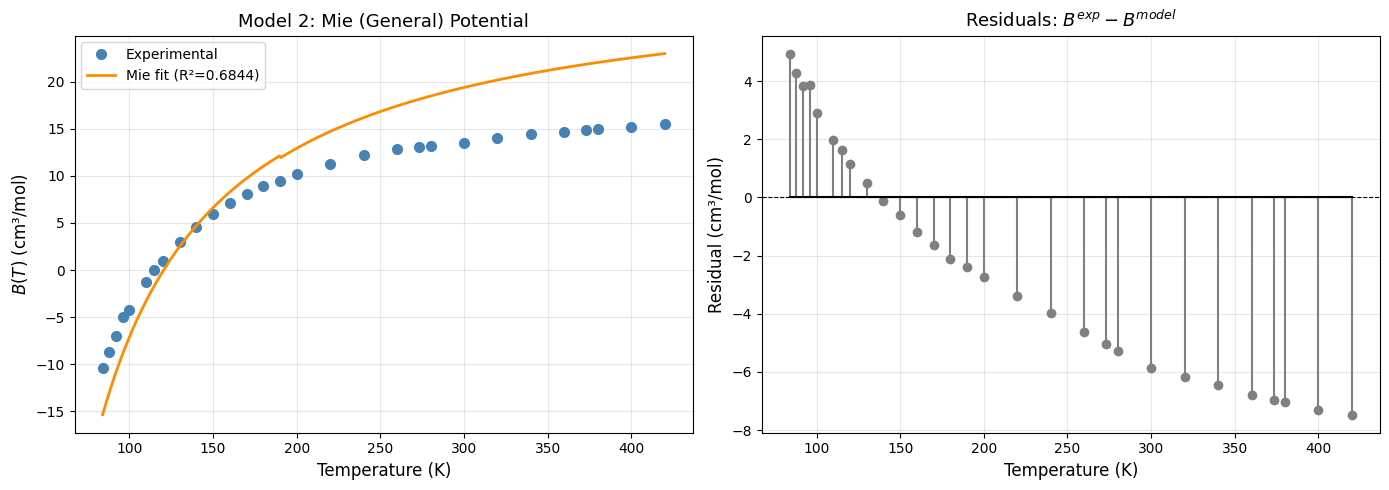

In [13]:
# ── Model 2: Fit Mie potential to data ─────────────────────────────────────
def calc_SSE_mie(params, T, B_exp):
    """SSE for Model 2 (Mie potential)."""
    residuals = B_exp - B_mie(params, T)
    return 0.5 * np.dot(residuals, residuals)

# ── Initial guesses ────────────────────────────────────────────────────────
# ε/kB ~ 40 K (D₂ literature);  m = 12 (Lennard-Jones starting point)
eps2_0 = 40.0 * kB      # [J]  →  ε/kB ≈ 40 K
m_0    = 12.0            # repulsive exponent (LJ as starting point)
params2_0 = [eps2_0, m_0]
print(f"Initial guesses:  ε₀/kB = {eps2_0/kB:.1f} K,  m₀ = {m_0}")

# ── Optimization (Nelder-Mead — slower due to numerical integration) ─────
print("\nOptimizing... (this may take a minute due to numerical integration)")
result_Mie = minimize(calc_SSE_mie, params2_0, args=(T_data, B_data),
                      method='Nelder-Mead',
                      options={'disp': True, 'maxiter': 10000,
                               'xatol': 1e-15, 'fatol': 1e-10})

eps2_fit, m_fit = result_Mie.x
print(f"\n{'='*55}")
print(f"  Mie Potential Fitted Parameters")
print(f"{'='*55}")
print(f"  ε (well depth)       = {eps2_fit:.6e} J  (ε/kB = {eps2_fit/kB:.2f} K)")
print(f"  m (repulsive exp.)   = {m_fit:.4f}")
print(f"  Final SSE            = {result_Mie.fun:.6e}")
print(f"{'='*55}")

# ── Evaluate model and compute error metrics ──────────────────────────────
B_pred_Mie = B_mie([eps2_fit, m_fit], T_data)
R2_Mie     = r2_score(B_data, B_pred_Mie)
RMSE_Mie   = np.sqrt(mean_squared_error(B_data, B_pred_Mie))
print(f"\n  R² = {R2_Mie:.6f}")
print(f"  RMSE = {RMSE_Mie:.4f} cm³/mol")

# ── Plot fitted model vs. data ────────────────────────────────────────────
B_model_Mie = B_mie([eps2_fit, m_fit], T_smooth)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(T_data, B_data, 'o', color='steelblue', ms=7, label='Experimental')
axes[0].plot(T_smooth, B_model_Mie, '-', color='darkorange', lw=2,
             label=f'Mie fit (R²={R2_Mie:.4f})')
axes[0].set_xlabel('Temperature (K)', fontsize=12)
axes[0].set_ylabel('$B(T)$ (cm³/mol)', fontsize=12)
axes[0].set_title('Model 2: Mie (General) Potential', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

residuals_Mie = B_data - B_pred_Mie
axes[1].stem(T_data, residuals_Mie, linefmt='grey', markerfmt='o', basefmt='k-')
axes[1].axhline(y=0, color='black', ls='--', lw=0.8)
axes[1].set_xlabel('Temperature (K)', fontsize=12)
axes[1].set_ylabel('Residual (cm³/mol)', fontsize=12)
axes[1].set_title('Residuals: $B^{exp} - B^{model}$', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a id="6-comparison"></a>
## 6. Model Comparison & Error Analysis

We now compare both models side-by-side to determine which potential minimizes the prediction error most effectively. The key metrics are:

- **R²** (coefficient of determination): measures the fraction of variance explained (closer to 1 is better)
- **RMSE** (root mean squared error): measures average prediction error in the same units as $B(T)$
- **SSE** (sum of squared errors): the objective function we minimized

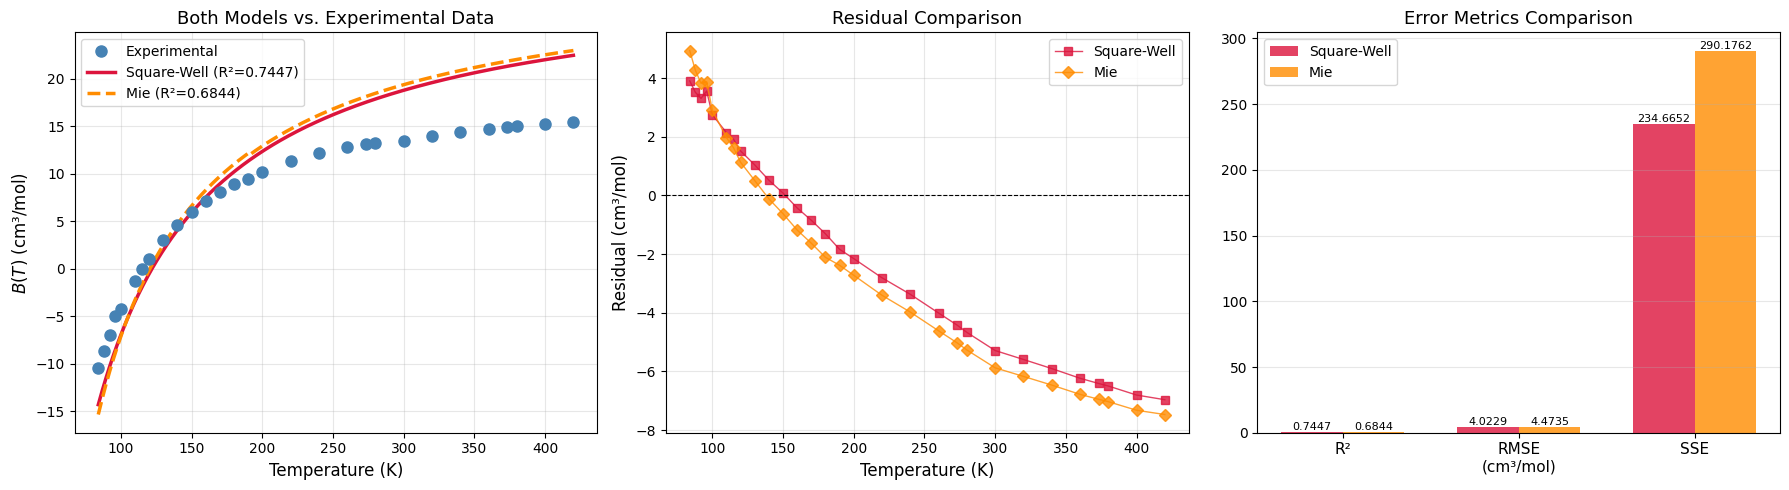


  Model Comparison Summary
  Metric                        Square-Well             Mie
  -------------------------------------------------------
  R²                               0.744737        0.684353
  RMSE (cm³/mol)                     4.0229          4.4735
  SSE                          2.346652e+02    2.901762e+02
  ε (J)                        1.402245e-27    5.663697e-22
  ε/kB (K)                             0.00           41.02
  2nd param                  a=3.1122e-08 m       m=11.6346

  → Best model (highest R²): Square-Well


In [14]:
# ── Side-by-side comparison plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Both models overlaid on data
axes[0].plot(T_data, B_data, 'o', color='steelblue', ms=8, label='Experimental', zorder=5)
axes[0].plot(T_smooth, B_model_SW, '-', color='crimson', lw=2.5, label=f'Square-Well (R²={R2_SW:.4f})')
axes[0].plot(T_smooth, B_model_Mie, '--', color='darkorange', lw=2.5, label=f'Mie (R²={R2_Mie:.4f})')
axes[0].set_xlabel('Temperature (K)', fontsize=12)
axes[0].set_ylabel('$B(T)$ (cm³/mol)', fontsize=12)
axes[0].set_title('Both Models vs. Experimental Data', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel 2: Residuals comparison
axes[1].plot(T_data, residuals_SW, 's-', color='crimson', ms=6, lw=1, alpha=0.8, label='Square-Well')
axes[1].plot(T_data, residuals_Mie, 'D-', color='darkorange', ms=6, lw=1, alpha=0.8, label='Mie')
axes[1].axhline(y=0, color='black', ls='--', lw=0.8)
axes[1].set_xlabel('Temperature (K)', fontsize=12)
axes[1].set_ylabel('Residual (cm³/mol)', fontsize=12)
axes[1].set_title('Residual Comparison', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Panel 3: Error metrics bar chart
metrics = ['R²', 'RMSE\n(cm³/mol)', 'SSE']
sw_vals  = [R2_SW, RMSE_SW, result_SW.fun]
mie_vals = [R2_Mie, RMSE_Mie, result_Mie.fun]

x = np.arange(len(metrics))
width = 0.35
bars1 = axes[2].bar(x - width/2, sw_vals, width, color='crimson', alpha=0.8, label='Square-Well')
bars2 = axes[2].bar(x + width/2, mie_vals, width, color='darkorange', alpha=0.8, label='Mie')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics, fontsize=11)
axes[2].set_title('Error Metrics Comparison', fontsize=13)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  Model Comparison Summary")
print(f"{'='*65}")
print(f"  {'Metric':<25s} {'Square-Well':>15s} {'Mie':>15s}")
print(f"  {'-'*55}")
print(f"  {'R²':<25s} {R2_SW:>15.6f} {R2_Mie:>15.6f}")
print(f"  {'RMSE (cm³/mol)':<25s} {RMSE_SW:>15.4f} {RMSE_Mie:>15.4f}")
print(f"  {'SSE':<25s} {result_SW.fun:>15.6e} {result_Mie.fun:>15.6e}")
print(f"  {'ε (J)':<25s} {eps_fit:>15.6e} {eps2_fit:>15.6e}")
print(f"  {'ε/kB (K)':<25s} {eps_fit/kB:>15.2f} {eps2_fit/kB:>15.2f}")
print(f"  {'2nd param':<25s} {'a='+f'{a_fit:.4e} m':>15s} {'m='+f'{m_fit:.4f}':>15s}")
print(f"{'='*65}")

# Determine the winner
if R2_SW > R2_Mie:
    best = "Square-Well"
else:
    best = "Mie"
print(f"\n  → Best model (highest R²): {best}")